# Continuous-Time Gaussian-Process Trajectory Estimation on SE(3) with a White Noise on Acceleration Prior

This notebook demonstrates how to use the `gtsam` library to perform continuous-time (CT) trajectory estimation on SE(3) using a white noise on acceleration (WNOA) prior. We use a simple trajectory example that is based on the example given in ___ . The functions shown herein are based on the GTSAM additions that were developed as a contribution of this paper. 

In particular, we use the GTSAM framework to show:
- How to add WNOA priors to smooth a trajectory and endow a solution with a Gaussian Process (GP) interpretation
- How to interpolate new states from the factor graph solution based on GP regression
- How to integrate measurements on interpolated states into a factor graph without explicitly optimizing these states
- How to convert a standard factor graph into an equivalent graph with some of its states interpolated (and thus removed from the optimization)

Currently, the framework supports interpolation on the following types:
- `Point1`
- `Point2`
- `Point3`
- `Pose2`
- `Pose3`

In this example, we demonstrate our framework on the `Pose3` class.

Author: Connor Holmes

In [90]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

GTSAM Copyright 2010-2022, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [91]:
import gtsam
import numpy as np
from typing import List

from gtsam import Pose3, StateData
from gtsam import updateInterpValuesWithCovariancePose3 as update


# Plotting tools
from GaussianProcessWnoaInterpolationSE3Helpers import collect_estimated_plot_data, collect_interp_plot_data, plot_results

## Setup and Ground Truth

We start by defining the ground-truth values for the trajectory that we wish to estimate. To start, we will use `K+1` estimated states (`K` intervals), but we will use interpolation to upsample the ground-truth trajectory at a higher rate of `K_sample`. 

We separate the ground-truth trajectory into two GTSAM `Values` objects: one for the states at the estimation rate (`K+1` states) and one for the states at the interpolation rate (`K_sample*K+1` states). 

In [92]:

# Number of intervals
K = 7 
# Interpolation upsampling rate
K_sample = 5
# Time interval of trajectory
tmax = 10 

# Seed  (for reproducibility)
np.random.seed(42)

# number of intervals
K_all = K_sample*K
# all times  (including interpolation)
times_all = np.linspace(0, tmax, K_all+1)

# Loop through all times (including interpolated times) to compute the ground-truth trajectory
values_gt = gtsam.Values()
for k in range(K_all+1):
    # Define 6dof GT velocity and add to values
    velocity = np.array([0, 0, -0.3*np.sin(2*np.pi*times_all[k]/tmax), -1, 0, 0]).reshape(6,1)
    # Add pose to values
    if k == 0:
        pose = Pose3.Expmap(np.zeros(6))
    else:
        delta_t = (times_all[k]-times_all[k-1])
        rel_pose = Pose3.Expmap(velocity*delta_t)
        pose = rel_pose.compose(pose)
    # Non-interpolated values for estimation
    values_gt.insert(gtsam.symbol('x', k), pose)
    values_gt.insert(gtsam.symbol('v', k), velocity)
    



## Defining the States

We need a way to keep track of which pose and velocity keys correspond to a given time `t`. To do so, we make use of the `StateData` class, which provides a convenient way to manage the keys for the states at both the interpolation and estimation rates.

We also want to keep track of the states that will be estimated via optimization and those that will be simply interpolated. As such, we define two lists of keys: the interpolated states, `interp_states`, and the states that are actually solved for in the estimation, `est_states`. 

In [93]:
interp_states: List[StateData] = []
est_states: List[StateData] = []
for k in range(K_all+1):
    state_data = StateData(gtsam.symbol('x', k), gtsam.symbol('v', k), times_all[k])
    if k % K_sample == 0:
        est_states.append(state_data)
    else:
        interp_states.append(state_data)

## Defining the Factor Graph

We now define a simple factor graph with unary factors on the estimated states and WNOA motion factors between consecutive states. When defining the WNOA motion factors, we need specify the `StateData` objects that correspond to the two states that the factor connects. This allows the factor to perform interpolation at the correct times when evaluating the error and Jacobians. These motion factors also need to be provided the power spectral density matrix `Qc` that defines the WNOA prior. 

In [94]:
# Measurement covariance and noise model
R_meas = 1e-2*np.diag([0.1, 0.1, 0.1, 1, 1, 1])
noise_model = gtsam.noiseModel.Gaussian.Covariance(R_meas)
# Power Spectral Density Matrix for the GP Prior (diagonal-only)
Qc = 0.008*np.array([0.1, 0.1, 0.1, 1, 1, 1])

# Create a graph for the estimated states
graph = gtsam.NonlinearFactorGraph()
# Add factors
meas_poses = []
for k in range(K+1):
    # Get the current state
    curr_state: StateData = est_states[k]
    # Get measurement perturbation due to noise
    xi_pert = np.sqrt(R_meas)@np.random.randn(6,1)
    xi_pert = np.vstack([xi_pert[3:,:], xi_pert[:3,:]]) # Consistent with paper plot
    pose_pert = gtsam.Pose3.Expmap(xi_pert)
    pose_meas = pose_pert.compose(values_gt.atPose3(curr_state.pose))
    meas_poses.append(pose_meas) # Keep track for plotting
    
    # Add measurement
    graph.addPriorPose3(curr_state.pose, pose_meas,noise_model)
    
    # Add WNOA Motion Factor
    if k>0:
        prev_state = est_states[k-1]
        graph.add(gtsam.WnoaMotionFactorPose3(prev_state, curr_state, Qc))  

## Optimization

We are ready to optimize! We generate an initial guess for the trajectory by starting at the ground-truth initial pose and then rolling out the trajectory mean using the initial twist `varpi_0`. After optimization, we can evaluate the results by comparing the estimated trajectory to the ground-truth trajectory. 

In [95]:
# Define the constant velocity estimate (not equal to GT)
varpi_0 = np.array([0, 0, 0,-1.0, 0, 0]).reshape(6,1)
# Generate the initial trajectory values at the estimation rate
values_init = gtsam.Values()

# Start from the ground-truth initial pose
pose_init = values_gt.atPose3(est_states[0].pose)
values_init.insert(est_states[0].pose, pose_init)
values_init.insert(est_states[0].velocity, varpi_0)

# Roll out using the constant twist varpi_0
prev_pose = pose_init
prev_time = est_states[0].time
for state in est_states[1:]:
    delta_t = state.time - prev_time
    rel_pose = Pose3.Expmap(varpi_0 * delta_t)
    prev_pose = rel_pose.compose(prev_pose)
    values_init.insert(state.pose, prev_pose)
    values_init.insert(state.velocity, varpi_0)
    prev_time = state.time
    
# Define the optimizer and optimize the graph
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, values_init)
result = optimizer.optimize()


The result of our optimization is plotted in the next cell. The dark blue frames and covariance ellipsoids correspond to the estimates and the red frames correspond to noisy measurements. The ground truth values are shown as green frames. We note that the WNOA prior smooths out the trajectory, splitting the difference between the noisy pose measurements.

We also use the `Marginal` class to extract and plot the marginal covariances of the states.

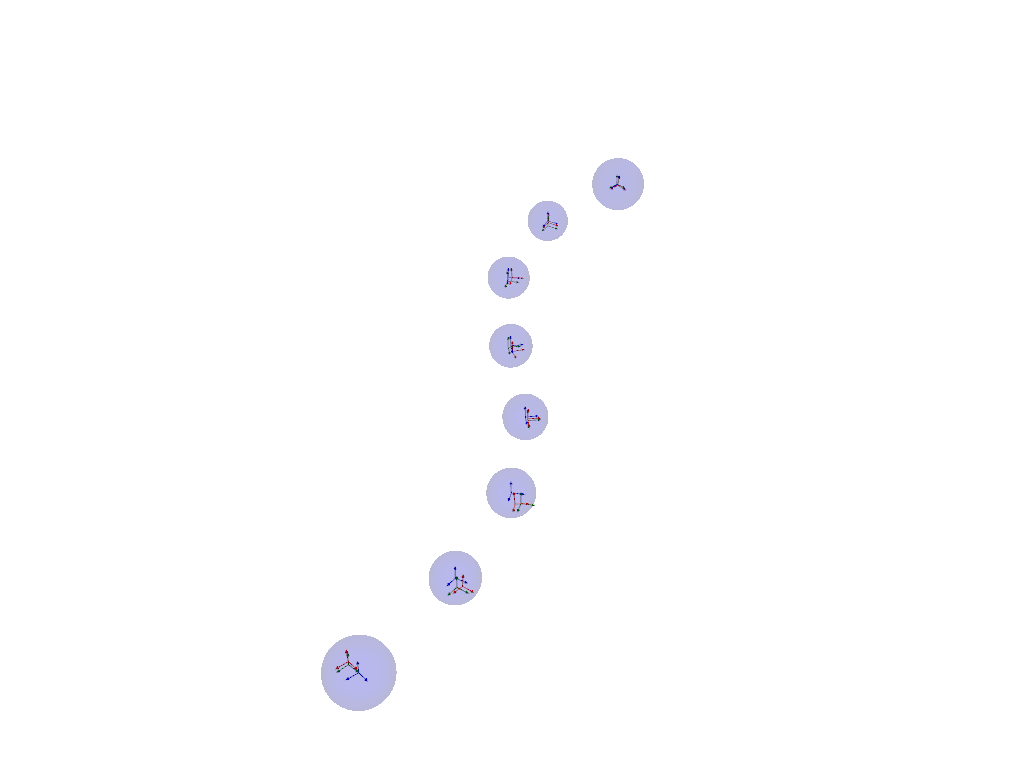

In [96]:
# Define marginal class to recover marginal covariances
marginals = gtsam.Marginals(graph, result)
# Get estimated poses, ground-truth poses and covariances
poses, poses_gt, covariances = collect_estimated_plot_data(
    result=result,
    values_gt=values_gt,
    marginals=marginals,
    est_states=est_states,
    )
# Plot the results
plot_results(
    poses=poses,
    poses_gt=poses_gt,
    covariances=covariances,
    meas_poses=meas_poses,
 )


## Interpolating from the estimated states

Crucially, our use of the WNOA GP prior now allows us to sample the continuous-time trajectory at any time by interpolating between the estimated states. This is easily accomplished using the `updateInterpValues` function. If we want to also retrieve the covariances, we can do so with the `updateInterpValuesWithCovariance` function. Note that all the relevent information relating the estimation states to the interpolated states is contained in the `StateData` objects. 

Below we interpolate the states that have already been marked for interpolation in `interp_states`. We then reproduce the same plot as above with the interpolated states and their covariances.

Done interpolating!
Starting render...


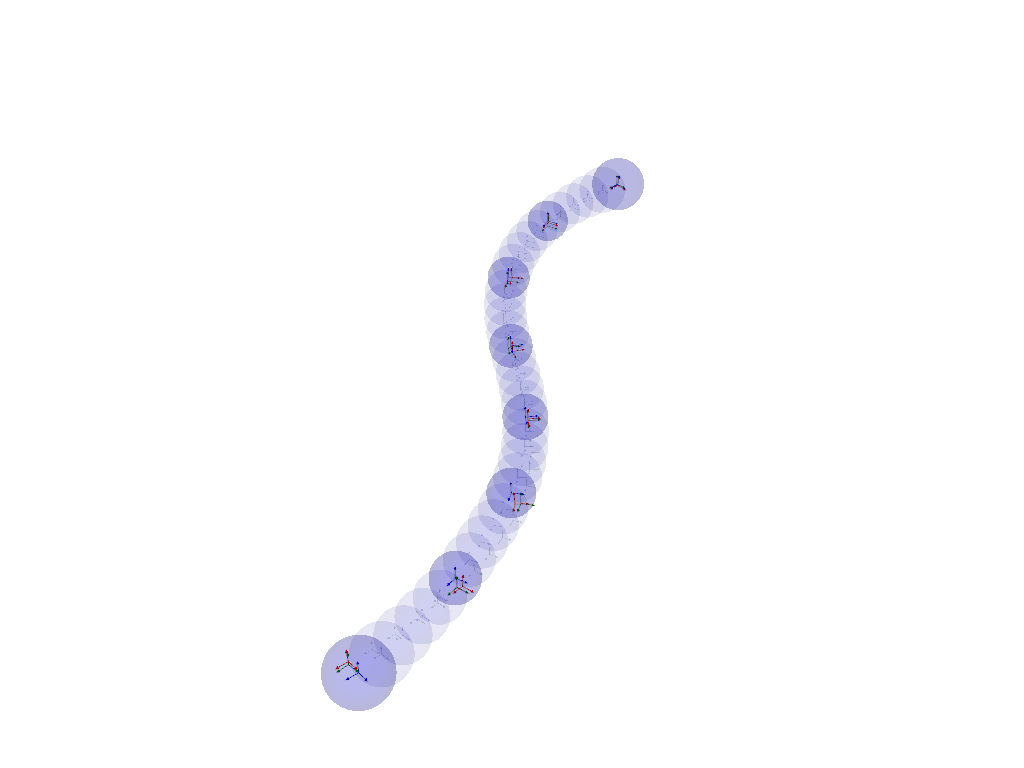

In [97]:

# Update the values by GP interpolation
values_interp, cov_interp = update(
    graph, result, set(est_states), set(interp_states), Qc
    )
print("Done interpolating!")
# Gather poses for plotting
poses_int, poses_int_gt, covariances_int = collect_interp_plot_data(
    values_interp=values_interp,
    values_gt=values_gt,
    marginals=marginals,
    interp_states=interp_states,
    cov_interp=cov_interp,
    )

print("Starting render...")
plot_results(
    poses=poses,
    poses_gt=poses_gt,
    covariances=covariances,
    meas_poses=meas_poses,
    poses_int=poses_int,
    covariances_int=covariances_int,
    poses_int_gt=poses_int_gt,
    )

## Measurements on Interpolated States

Above, we showed how to recover interpolated states *a posteriori* from the states that were directly optimized. However, one of the benefits of CT-GP estimation is that we can also include the effect of measurement factors that are defined on interpolated states. We demonstrate this idea in the cell below, where we add measurement factors on interpolated states at the midpoints between the estimated states.

To define a factor on an interpolated state, we first create a standard GTSAM factor, treating the interpolated state keys as if they are standard variables in the factor graph. We then pass this factor to our `WnoaInterpFactor` wrapper factor, along with a set of the estimated and interpolated `StateData` objects and information about the WNOA prior. The wrapper factor handles all of the interpolation calculations internally, inferring interpolation relationships from the inputs.

We print the keys before and after adding the new factors to show that they do not change (since we are not changing the number of estimated states in the graph). We also print the last wrapped factor, which shows the interpolated states, the border estimated states used to interpolate it, and the original factor information.

In [98]:

print("Keys before adding new factors:")
print(", ".join([gtsam.Symbol(key).string() for key in list(graph.keys())]))

graph_w_interp_meas = gtsam.NonlinearFactorGraph(graph)
for k in range(K_all+1):
    if k % K_sample == K_sample // 2:
        # Get interpolated state
        int_state = StateData(gtsam.symbol('x', k), gtsam.symbol('v', k), times_all[k])
        # Define unary prior on the interpolated state
        xi_pert = np.sqrt(R_meas)@np.random.randn(6,1)
        pose_meas = gtsam.Pose3.Expmap(xi_pert).compose(values_gt.atPose3(int_state.pose))       
        meas_poses.append(pose_meas) # Keep track for plotting
        # Get standard unary prior factor
        factor = gtsam.PriorFactorPose3(int_state.pose, pose_meas, noise_model)
        # Wrap with WNOA Interpolation factor
        factor_wrapped = gtsam.WnoaInterpFactorPose3(
            factor, set(est_states), set([int_state]), Qc
            )
        graph_w_interp_meas.add(factor_wrapped)

print("Keys after adding new factors:")
print(", ".join([gtsam.Symbol(key).string() for key in list(graph_w_interp_meas.keys())]))
print("\n")
factor_wrapped.print("The wrapped factor:\n")


Keys before adding new factors:
v0, v5, v10, v15, v20, v25, v30, v35, x0, x5, x10, x15, x20, x25, x30, x35
Keys after adding new factors:
v0, v5, v10, v15, v20, v25, v30, v35, x0, x5, x10, x15, x20, x25, x30, x35


The wrapped factor:
WnoaInterpFactor on x35 v30 v35 x30 
Inner Factor: PriorFactor on x32
  prior mean:  R: [
	0.999729180, 0.016675661, -0.016232336;
	-0.016261348, 0.999546883, 0.025329763;
	0.016647371, -0.025058944, 0.999547355
]
t: -7.569206691 -4.243549115  0.035019149
  noise model: diagonal sigmas [0.031622777; 0.031622777; 0.031622777; 0.100000000; 0.100000000; 0.100000000];


Note that when we define the WNOA interpolation factor, we provided the full set of estimation states because it was convenient. However, we really only need to provide the two states that bound the state that is being interpolated (with respect to time). All interpolated states must be bounded by two states to properly define the factor.

We can now optimize the graph as before and plot our outputs.

Done interpolating!
Starting render...


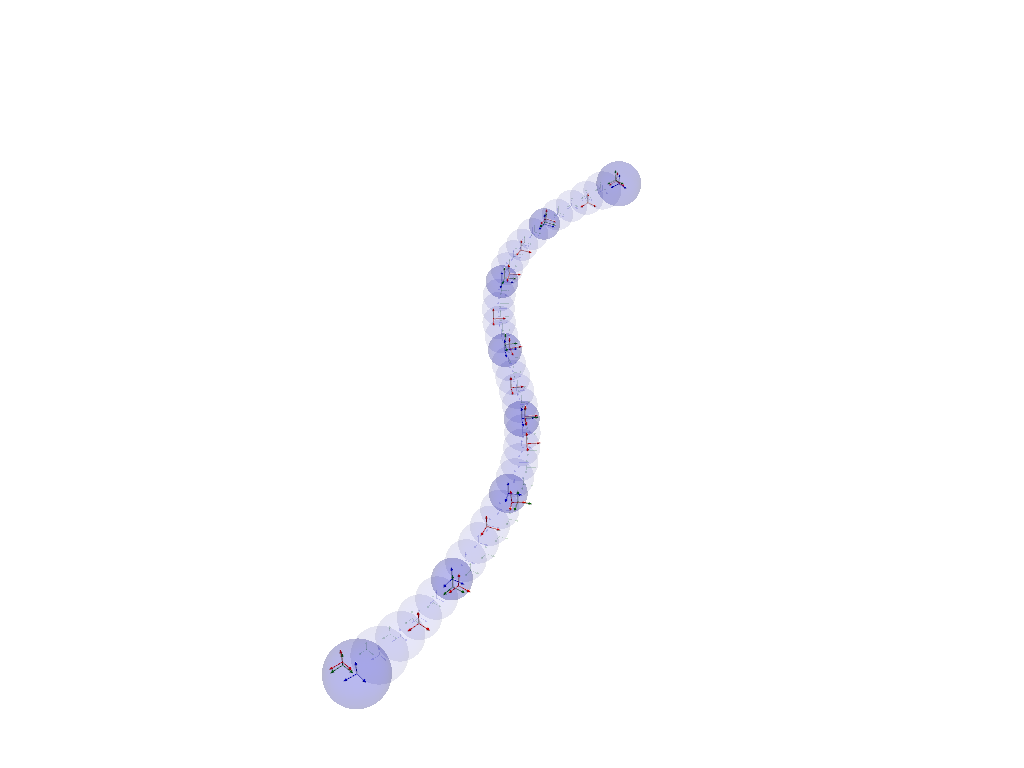

In [99]:
# Define the optimizer and optimize the graph
optimizer = gtsam.LevenbergMarquardtOptimizer(graph_w_interp_meas, values_init)
result = optimizer.optimize()

# Define marginal class to recover marginal covariances
marginals = gtsam.Marginals(graph_w_interp_meas, result)
# Update the values by GP interpolation
values_interp, cov_interp = update(
    graph_w_interp_meas, result, set(est_states), set(interp_states), Qc
    )
print("Done interpolating!")
# Get estimated poses, ground-truth poses and covariances
poses, poses_gt, covariances = collect_estimated_plot_data(
    result=result,
    values_gt=values_gt,
    marginals=marginals,
    est_states=est_states,
    )
# Get interpolated values
poses_int, poses_int_gt, covariances_int = collect_interp_plot_data(
    values_interp=values_interp,
    values_gt=values_gt,
    marginals=marginals,
    interp_states=interp_states,
    cov_interp=cov_interp,
    )

# Generate plot
print("Starting render...")
plot_results(
    poses=poses,
    poses_gt=poses_gt,
    covariances=covariances,
    meas_poses=meas_poses,
    poses_int=poses_int,
    covariances_int=covariances_int,
    poses_int_gt=poses_int_gt,
    )

# Automatic Factor Graph Conversion

To avoid tediously wrapping all of the factors that are interpolated we have generated a convenient function, `interpolateFactorGraph` that can be used to automatically wrap factors that are defined on interpolated states. This allows the user to build a factor graph using standard workflows, then convert it to an equivalent graph with selected states interpolated rather than directly optimized. This can be useful for exploring the effect of interpolating different states in the factor graph. 

We start by creating a new factor graph and adding the priors *as if we are not interpolating any states*

In [100]:

# Create new graph
graph = gtsam.NonlinearFactorGraph()
meas_poses = []
# Add measurement factors on estimated states and interpolated states
for k in range(K_all + 1):
    if k % K_sample == K_sample // 2 or k % K_sample == 0:
        # Get the current state (either interpolated or estimated)
        curr_state = StateData(gtsam.symbol('x', k), gtsam.symbol('v', k), times_all[k])
        # Get measurement perturbation due to noise
        xi_pert = np.sqrt(R_meas)@np.random.randn(6,1)
        xi_pert = np.vstack([xi_pert[3:,:], xi_pert[:3,:]]) # Consistent with paper plot
        pose_pert = gtsam.Pose3.Expmap(xi_pert)
        pose_meas = pose_pert.compose(values_gt.atPose3(curr_state.pose))
        meas_poses.append(pose_meas) # Keep track for plotting
        # Add measurement
        graph.addPriorPose3(curr_state.pose, pose_meas,noise_model)


Note that we did not add any WNOA motion prior to the factor graph. This is because the conversion function will automatically add WNOA priors between adjacent estimated states in the graph.

Below, we convert the graph, optimize, and generate the trajectory plot, as before.

Done interpolating!
Starting render...


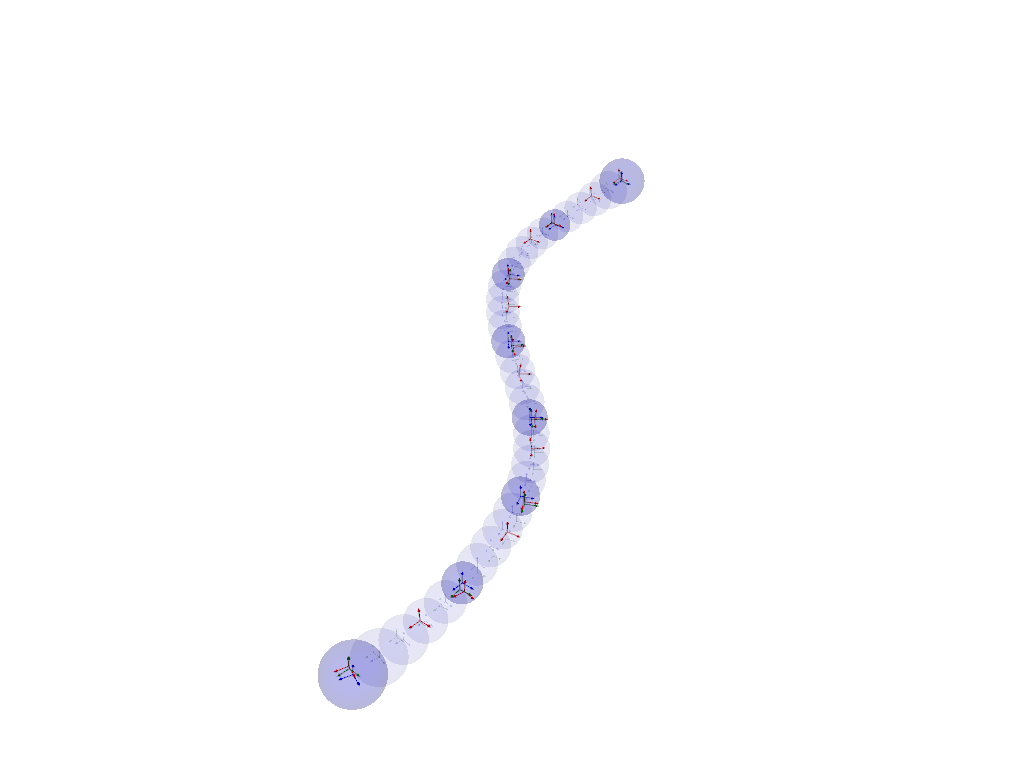

In [101]:

graph_interp = gtsam.interpolateFactorGraphPose3(
    graph, set(est_states), set(interp_states), Qc
)

# Define the optimizer and optimize the graph
optimizer = gtsam.LevenbergMarquardtOptimizer(graph_interp, values_init)
result = optimizer.optimize()

# Define marginal class to recover marginal covariances
marginals = gtsam.Marginals(graph_w_interp_meas, result)
# Update the values by GP interpolation
values_interp, cov_interp = update(
    graph_w_interp_meas, result, set(est_states), set(interp_states), Qc
    )
print("Done interpolating!")
# Get estimated poses, ground-truth poses and covariances
poses, poses_gt, covariances = collect_estimated_plot_data(
    result=result,
    values_gt=values_gt,
    marginals=marginals,
    est_states=est_states,
    )
# Get interpolated values
poses_int, poses_int_gt, covariances_int = collect_interp_plot_data(
    values_interp=values_interp,
    values_gt=values_gt,
    marginals=marginals,
    interp_states=interp_states,
    cov_interp=cov_interp,
    )

# Generate plot
print("Starting render...")
plot_results(
    poses=poses,
    poses_gt=poses_gt,
    covariances=covariances,
    meas_poses=meas_poses,
    poses_int=poses_int,
    covariances_int=covariances_int,
    poses_int_gt=poses_int_gt,
    )